# Compare LOV binders in light and dark conditions

This notebook reads both accepted binder sequences from `results/LOV_local/final_design_stats.csv` and predicts their complexes with **2V1B (Light)** and **2V1A (Dark)** using chain A. The defaults give **8 predictions**: 2 binders x 2 conditions x 2 AF2 models x 1 seed, with 3 recycles. Inputs, model/seed scores, PDBs, tables, and plots are saved in a new folder under `results/LOV_local/light_dark_comparison/`.

Use the same Windows Python kernel as `BindCraft_local.ipynb`; computations and plotting run in the existing Linux environment. Run this after other GPU jobs finish. The prediction cell shows progress and finishes automatically; rerun only the display cell to view existing results. Interrupting the prediction cell requests a stop after the current prediction.

Both condition PDBs have the same chain-A sequence and residues **403–546**. The earlier `2V1B_exposed.pdb` design target contains only **403–520**; this comparison includes the full supplied structures. State assignments are documented by [RCSB 2V1B](https://www.rcsb.org/structure/2V1B) and [RCSB 2V1A](https://www.rcsb.org/structure/2V1A).

These are protein-template confidence comparisons. AlphaFold may move the target; this workflow does not model FMN photochemistry or measure binding affinity. Treat the mean differences as exploratory scores, not proof of light selectivity.


In [1]:
# Locate this checkout and select the existing Linux compute environment.
import csv
import html
import json
import os
import re
import shutil
import subprocess
import sys
import textwrap
import uuid
from datetime import datetime
from pathlib import Path, PurePosixPath
from IPython.display import HTML, display

REPO_OVERRIDE = ""  # Usually leave empty; otherwise use a path visible to this kernel.
WSL_DISTRO = "Ubuntu"
LINUX_PYTHON = "/home/fereshteh/miniconda3/envs/BindCraft/bin/python"
LINUX_CONDA = "/home/fereshteh/miniconda3/bin/conda"

def find_repo():
    if REPO_OVERRIDE:
        candidates = [Path(REPO_OVERRIDE).expanduser()]
    else:
        here = Path.cwd().resolve()
        candidates = [here, *here.parents]
        candidates += [Path(r"C:\Users\Feres\Dropbox\Projects\BindCraft\BindCraft")
                       if os.name == "nt" else
                       Path("/mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft")]
    for candidate in candidates:
        if (candidate / "bindcraft.py").is_file() and (candidate / "functions").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Set REPO_OVERRIDE to the folder containing bindcraft.py.")

REPO_ROOT = find_repo()
USE_WSL = os.name == "nt"
HOST_PROCESS_OPTIONS = {"creationflags": subprocess.CREATE_NO_WINDOW} if USE_WSL else {}
if USE_WSL and not shutil.which("wsl.exe"):
    raise RuntimeError("wsl.exe was not found. Open this notebook in Ubuntu Jupyter.")
if not USE_WSL and not sys.platform.startswith("linux"):
    raise RuntimeError("The compute runtime must be Linux or Windows with WSL2.")

def local_path(value):
    """Interpret user paths on the notebook side; relative paths start at the repo."""
    value = str(value)
    if USE_WSL:
        match = re.match(r"^/mnt/([a-zA-Z])/(.*)$", value)
        if match:
            value = match[1].upper() + ":/" + match[2]
        elif value.startswith("/"):
            raise ValueError("Use a Windows/shared-drive path with a Windows kernel: " + value)
    elif re.match(r"^[a-zA-Z]:[\\/]", value):
        value = "/mnt/" + value[0].lower() + "/" + value[3:].replace("\\", "/")
    path = Path(value).expanduser()
    return (path if path.is_absolute() else REPO_ROOT / path).resolve()

def runtime_path(value):
    path = local_path(value)
    if not USE_WSL:
        return str(path)
    completed = subprocess.run(
        ["wsl.exe", "-d", WSL_DISTRO, "--exec", "wslpath", "-a", "-u", str(path)],
        capture_output=True, text=True, encoding="utf-8", errors="replace", timeout=30,
        **HOST_PROCESS_OPTIONS,
    )
    if completed.returncode:
        raise RuntimeError(completed.stderr or completed.stdout)
    return completed.stdout.strip()

RUNTIME_ROOT = runtime_path(REPO_ROOT)
RUNTIME_PREFIX = str(PurePosixPath(LINUX_PYTHON).parent.parent)
LOCAL_STATE = REPO_ROOT / ".bindcraft-local"
LOCAL_STATE.mkdir(exist_ok=True)

def linux_command(argv):
    # Apply these before importing JAX. Do not propagate Windows CUDA paths to WSL.
    env = {
        "CONDA_PREFIX": RUNTIME_PREFIX,
        "PATH": RUNTIME_PREFIX + "/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/lib/wsl/lib",
        "LD_LIBRARY_PATH": RUNTIME_PREFIX + "/lib",
        "XLA_PYTHON_CLIENT_PREALLOCATE": "false",
        "PYTHONDONTWRITEBYTECODE": "1",
        "PYTHONUNBUFFERED": "1",
    }
    prefix = ["wsl.exe", "-d", WSL_DISTRO, "--exec"] if USE_WSL else []
    return prefix + ["env", *[f"{key}={value}" for key, value in env.items()], *map(str, argv)]

def run_python(source, args=(), timeout=180):
    # Send code through stdin, avoiding shell interpolation and Windows quoting issues.
    completed = subprocess.run(
        linux_command([LINUX_PYTHON, "-u", "-", *args]),
        input=textwrap.dedent(source), capture_output=True,
        text=True, encoding="utf-8", errors="replace", timeout=timeout,
        **HOST_PROCESS_OPTIONS,
    )
    if completed.returncode:
        raise RuntimeError(
            f"Compute process exited with {completed.returncode}:\n"
            + completed.stdout + completed.stderr
        )
    if completed.stderr.strip():
        print(completed.stderr.strip())
    return completed.stdout

print("Notebook Python:", sys.executable)
print("Repository:", REPO_ROOT)
print("Compute Python:", LINUX_PYTHON)
print("Compute repository:", RUNTIME_ROOT)
print(run_python("import sys; print('Connected:', sys.version.split()[0], sys.executable)"))

Notebook Python: /home/fereshteh/miniconda3/envs/BindCraft/bin/python
Repository: /mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft
Compute Python: /home/fereshteh/miniconda3/envs/BindCraft/bin/python
Compute repository: /mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft
Connected: 3.10.21 /home/fereshteh/miniconda3/envs/BindCraft/bin/python



In [2]:
# Paths are relative to the BindCraft repository root.
comparison_results_dir = "results/LOV_local"
comparison_targets = {
    "Light": "../LOV/2V1B.pdb",
    "Dark": "../LOV/2V1A.pdb",
}
comparison_ranks = [1, 2]
comparison_chain = "A"
comparison_use_multimer = False  # False: 2 template-enabled AF2 models; True: 5 AF-Multimer models.
comparison_seeds = [0]           # The same seeds are used in every binder/condition pair.
comparison_recycles = 3


In [3]:
# Run once to generate fresh predictions. The next cell redisplays saved results.
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from compare_binders_light_dark import run_comparison, show_comparison

comparison_dir = run_comparison(
    globals(),
    results_dir=comparison_results_dir,
    targets=comparison_targets,
    ranks=comparison_ranks,
    chain=comparison_chain,
    use_multimer=comparison_use_multimer,
    seeds=comparison_seeds,
    recycles=comparison_recycles,
)


Output: /mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft/results/LOV_local/light_dark_comparison/20260912_173545_9d8343


2 binders x 2 conditions x 2 models x 1 seeds = 8 predictions


The cell finishes automatically after predictions, tables, and plots are saved.


Loaded models: model_1_ptm, model_2_ptm


[1/8] Binder 1 / Light / model_1_ptm / seed 0


...

  File "/home/fereshteh/miniconda3/envs/BindCraft/lib/python3.10/logging/__init__.py", line 2183, in shutdown


    h.close()


  File "/home/fereshteh/miniconda3/envs/BindCraft/lib/python3.10/site-packages/absl/logging/__init__.py", line 1032, in close


    self.stream.close()


AttributeError: '_Tee' object has no attribute 'close'


Status: finished | 8/8 predictions | /mnt/c/Users/Feres/Dropbox/Projects/BindCraft/BindCraft/results/LOV_local/light_dark_comparison/20260912_173545_9d8343



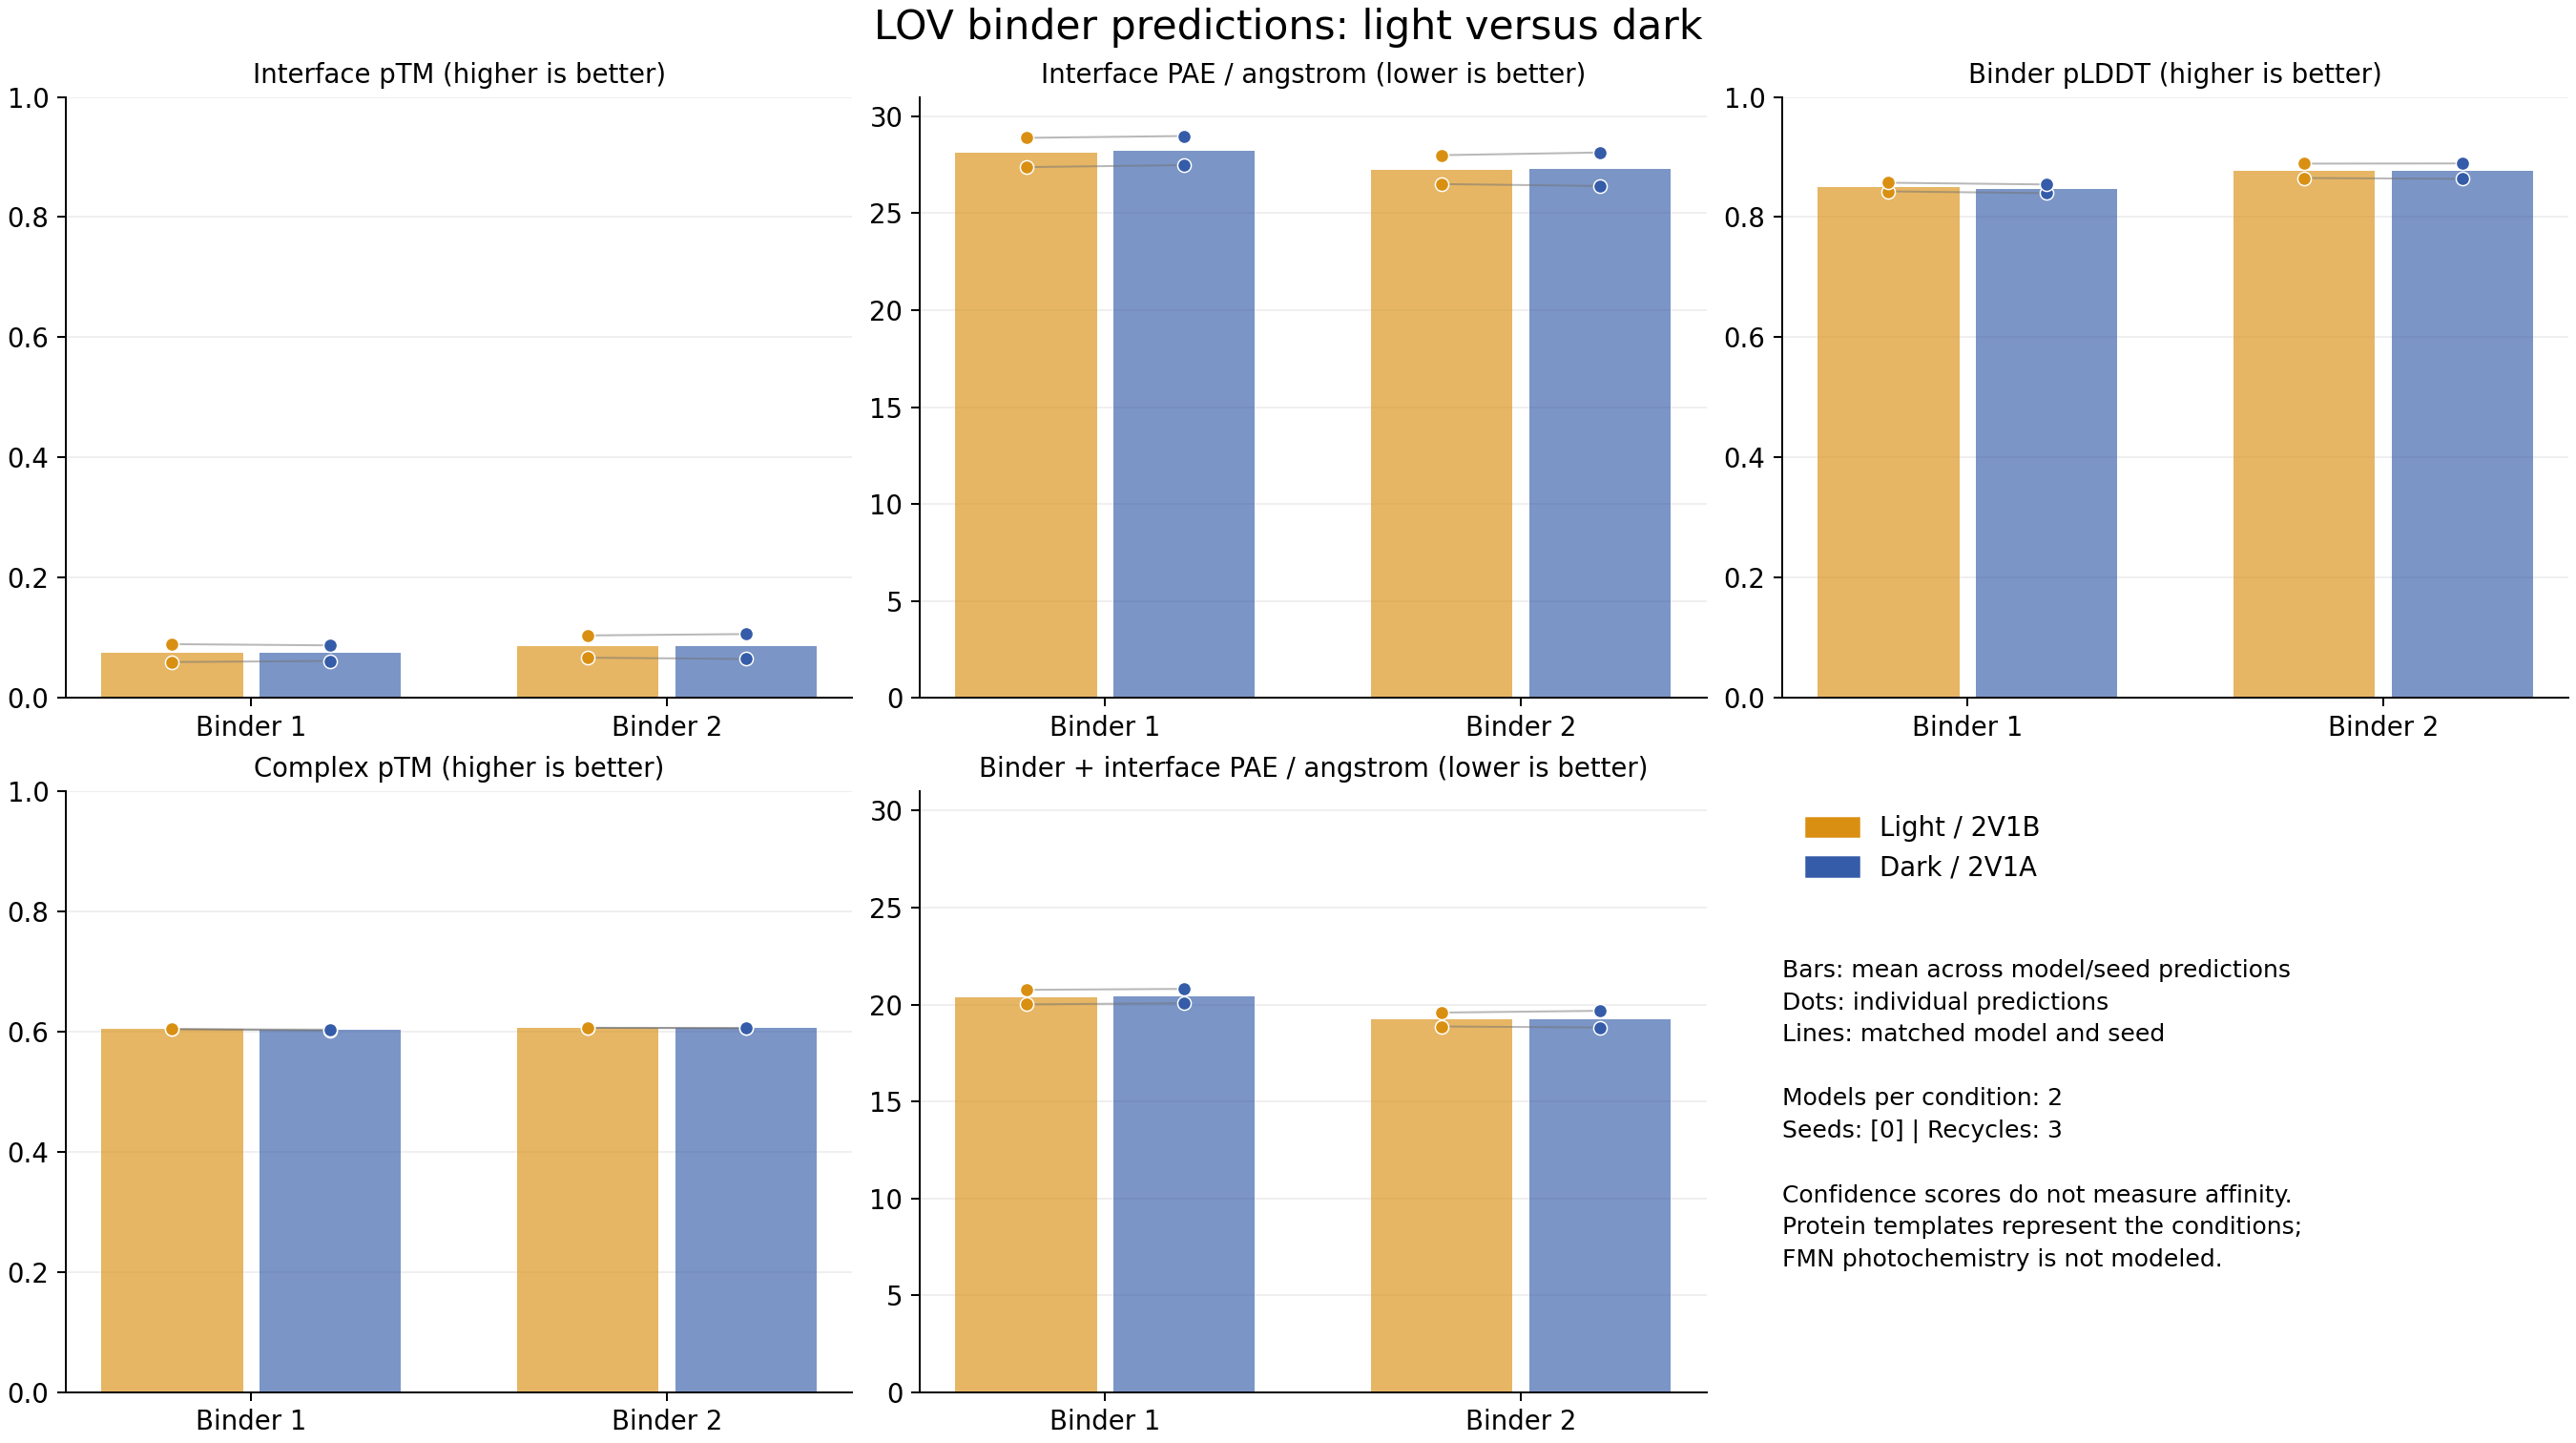

In [4]:
# Rerun this cell to print/plot saved results, without rerunning predictions.
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from compare_binders_light_dark import show_comparison

if "comparison_dir" not in globals():
    saved = sorted((local_path(comparison_results_dir) / "light_dark_comparison").glob("*/status.json"))
    if not saved:
        raise FileNotFoundError("Run the comparison cell first.")
    comparison_dir = saved[-1].parent
show_comparison(comparison_dir)


## Reading the output

- **i_pTM**: interface confidence; higher is better.
- **i_pAE_A**: interface predicted aligned error in angstroms; lower is better.
- **pLDDT**: binder confidence on a 0–1 scale; higher is better.
- **pTM**: complex confidence; higher is better.
- **pAE_A**: the ColabDesign binder-plus-interface PAE summary, converted to angstroms.

The raw CSV also retains the original normalized `pAE` and `i_pAE` scores. Angstrom values are those scores multiplied by 31, matching this installed ColabDesign version.

The difference table always reports **Light minus Dark**. Positive `delta_i_pTM` and negative `delta_i_pAE_A` favor Light by those confidence metrics. Plot bars show means, dots show individual predictions, and lines connect matching model/seed pairs. Models and seeds are not independent experimental replicates.

Each output folder contains `all_predictions.csv`, `condition_summary.csv`, `paired_light_minus_dark.csv`, `mean_light_minus_dark.csv`, `comparison.png`, `comparison.pdf`, a self-contained `report.html`, input snapshots, `status.json`, `run.log`, and predicted complexes under `pdbs/`.
